# ExRec Logical Error Distribution
## Syndrome-conditioned logical error analysis for full and truncated exRecs

**Circuit structures analysed:**
- **Full exRec**: `s_in â”€â”€â–º FTEC_a â”€â”€â–º [fault_0] â”€â”€â–º GATE â”€â”€â–º [fault_1] â”€â”€â–º FTEC_b â”€â”€â–º (L, s_out)`
- **Truncated exRec**: `s_in â”€â”€â–º FTEC_a â”€â”€â–º [fault_0] â”€â”€â–º GATE â”€â”€â–º *(star) â”€â”€â–º (L, s_out)`

The star decoder `*` measures the syndrome of whatever error is present and applies a virtual correction â€” its output syndrome `s_out` feeds into the next exRec as `s_in`.

**Key question**: for a sampled fault path, how does the input syndrome `s_in` determine the probability of each logical error `{I, X, Y, Z}`?

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from StabilizerCode import StabilizerCode

from pauli_utils import (pauli_str, str_to_pauli, pauli_weight, all_n_qubit_paulis,
    PAULI_LABEL, PAULI_FROM_CH, LOGICAL_NAMES,
    gate_identity, gate_hadamard, gate_phase_S, gate_phase_Sdg, make_custom_gate)

In [25]:
def get_logical_error(code, s_in, fault_path, gate_action):
    """
    Compute the logical error and output syndrome for one exRec.

    Parameters
    ----------
    code : StabilizerCode
    s_in : int
        Incoming syndrome to the leading FTEC_a.
    fault_path : list of (xvec, zvec)
        len == 1 -> truncated exRec  (FTEC - GATE - *)
        len == 2 -> full exRec       (FTEC - GATE - FTEC)
    gate_action : callable  (xvec, zvec) -> (xvec', zvec')

    Returns
    -------
    L     : int   0=I, 1=X, 2=Y, 3=Z
    s_out : int
    """
    Qx, Qz = code.corrections[s_in]
    xE, zE = Qx.copy(), Qz.copy()

    xf0, zf0 = fault_path[0]
    xE ^= xf0
    zE ^= zf0

    #first FTEC
    s_1 = code.compute_syndrome(xE,zE)
    Q1x,Q1z = code.corrections[s_1]
    xE ^= Q1x
    zE ^= Q1z


    xE, zE = gate_action(xE, zE)

    if len(fault_path) >= 2:
        xf1, zf1 = fault_path[1]
        xE ^= xf1
        zE ^= zf1

    s_out = code.compute_syndrome(xE, zE)
    Rx, Rz = code.corrections[s_out]
    xRes = xE ^ Rx
    zRes = zE ^ Rz

    L, _ = code.logical_class(xRes, zRes)
    return L, s_out


# ---------------------------------------------------------------------------
# Fault path sampling
# ---------------------------------------------------------------------------

def depolarizing_prob(xv, zv, p):
    """Probability of Pauli (xv,zv) under independent single-qubit depolarizing(p)."""
    w = int(np.sum(xv | zv))
    n = len(xv)
    return (p / 3) ** w * (1 - p) ** (n - w)


def sample_fault_path(code, p, n_locations, rng=None):
    """
    Sample one fault path of `n_locations` independent n-qubit depolarizing errors.
    Vectorized: generates all qubit errors at once per location.
    """
    if rng is None:
        rng = np.random.default_rng()
    n = code.n
    fault_path = []
    for _ in range(n_locations):
        r = rng.random(n)
        xv = np.zeros(n, dtype=int)
        zv = np.zeros(n, dtype=int)
        p3 = p / 3
        # X: r < p/3,  Y: p/3 <= r < 2p/3,  Z: 2p/3 <= r < p
        mask_x = r < p3
        mask_y = (r >= p3) & (r < 2 * p3)
        mask_z = (r >= 2 * p3) & (r < p)
        xv[mask_x | mask_y] = 1
        zv[mask_y | mask_z] = 1
        fault_path.append((xv, zv))
    return fault_path


def enumerate_fault_paths(code, n_locations, max_weight=1):
    """
    Enumerate all fault paths up to total Pauli weight `max_weight`.
    Yields (fault_path, weight).
    """
    n = code.n
    all_paulis = all_n_qubit_paulis(n)

    def _rec(loc, remaining_weight, current):
        if loc == n_locations:
            yield list(current)
            return
        for xv, zv in all_paulis:
            w = int(np.sum(xv | zv))
            if w <= remaining_weight:
                current.append((xv.copy(), zv.copy()))
                yield from _rec(loc + 1, remaining_weight - w, current)
                current.pop()

    for fp in _rec(0, max_weight, []):
        total_w = sum(int(np.sum(xv | zv)) for xv, zv in fp)
        yield fp, total_w


# ---------------------------------------------------------------------------
# Distribution computation
# ---------------------------------------------------------------------------

def compute_logical_error_distribution(code, gate_action, p,
                                       exrec_type='full', max_weight=None):
    """
    Compute P(L, s_out | s_in) exactly by iterating over ALL fault paths.
    WARNING: exponential in n * n_locations -- only feasible for small codes
    or low max_weight.

    Returns
    -------
    dist : np.ndarray, shape (n_syndromes, n_syndromes, 4)
    """
    n_loc = 1 if exrec_type == 'truncated' else 2
    n_syn = code.n_syndromes

    if max_weight is None:
        all_paulis = all_n_qubit_paulis(code.n)
        fault_paths = list(product(all_paulis, repeat=n_loc))
    else:
        fault_paths = [fp for fp, _ in enumerate_fault_paths(
            code, n_loc, max_weight=max_weight)]

    dist = np.zeros((n_syn, n_syn, 4))
    for fp in fault_paths:
        fp_list = list(fp)
        prob = 1.0
        for xv, zv in fp_list:
            prob *= depolarizing_prob(xv, zv, p)
        if prob == 0.0:
            continue
        for s_in in range(n_syn):
            L, s_out = get_logical_error(code, s_in, fp_list, gate_action)
            dist[s_in, s_out, L] += prob

    row_sums = dist.sum(axis=(1, 2), keepdims=True)
    dist /= np.where(row_sums == 0, 1, row_sums)
    return dist


def monte_carlo_distribution(code, gate_action, p,
                             exrec_type='full', n_samples=500_000,
                             s_in_distribution='uniform', seed=None):
    """
    Estimate P(L, s_out | s_in) by Monte Carlo sampling.

    Returns
    -------
    dist        : np.ndarray shape (n_syn, n_syn, 4)
    s_in_counts : np.ndarray shape (n_syn,)
    """
    rng = np.random.default_rng(seed)
    n_syn = code.n_syndromes
    n_loc = 1 if exrec_type == 'truncated' else 2

    if s_in_distribution == 'uniform':
        s_in_probs = np.ones(n_syn) / n_syn
    else:
        s_in_probs = np.asarray(s_in_distribution, dtype=float)
        s_in_probs /= s_in_probs.sum()

    counts = np.zeros((n_syn, n_syn, 4), dtype=np.int64)
    s_in_counts = np.zeros(n_syn, dtype=np.int64)

    for _ in range(n_samples):
        s_in = int(rng.choice(n_syn, p=s_in_probs))
        fp = sample_fault_path(code, p, n_loc, rng=rng)
        L, s_out = get_logical_error(code, s_in, fp, gate_action)
        counts[s_in, s_out, L] += 1
        s_in_counts[s_in] += 1

    denom = s_in_counts[:, np.newaxis, np.newaxis].astype(float)
    denom = np.where(denom == 0, 1.0, denom)
    dist = counts / denom

    return dist, s_in_counts


# ---------------------------------------------------------------------------
# Analysis utilities
# ---------------------------------------------------------------------------

def marginal_L_given_sin(dist):
    """
    Marginalise P(L, s_out | s_in) over s_out to get P(L | s_in).

    Parameters
    ----------
    dist : np.ndarray  shape (n_syn, n_syn, 4)

    Returns
    -------
    marginal : np.ndarray  shape (n_syn, 4)
    """
    return dist.sum(axis=1)


def non_markovianity(marg):
    """
    Scalar non-Markovianity measure: average total-variation distance of
    each P(L | s_in) row from the syndrome-averaged marginal.

       NM = (1/n_syn) * sum_{s_in}  (1/2) * sum_L |P(L|s_in) - P_avg(L)|

    Returns (NM, p_avg).
    """
    p_avg = marg.mean(axis=0)
    tvd = 0.5 * np.abs(marg - p_avg[None, :]).sum(axis=1)
    return tvd.mean(), p_avg


## Code instantiations
The [[5,1,3]] perfect code is used as the default example. Adding another code is a matter of supplying its generators and logical operators.

In [15]:
# ---------------------------------------------------------------------------
# [[5,1,3]] perfect code  (Gottesman Table 3.2 / 3.4)
# ---------------------------------------------------------------------------
# Generators:  g1=XZZXI  g2=IXZZX  g3=XIXZZ  g4=ZXIXZ
# Logical XÌ„ = XXXXX,  Logical ZÌ„ = ZZZZZ

code_513 = StabilizerCode(
    n=5,
    generators=[
        (np.array([1,0,0,1,0]), np.array([0,1,1,0,0])),  # g1: XZZXI
        (np.array([0,1,0,0,1]), np.array([0,0,1,1,0])),  # g2: IXZZX
        (np.array([1,0,1,0,0]), np.array([0,0,0,1,1])),  # g3: XIXZZ
        (np.array([0,1,0,1,0]), np.array([1,0,0,0,1])),  # g4: ZXIXZ
    ],
    logical_x=(np.array([1,1,1,1,1]), np.array([0,0,0,0,0])),  # XXXXX
    logical_z=(np.array([0,0,0,0,0]), np.array([1,1,1,1,1])),  # ZZZZZ
    name='[[5,1,3]]',
)

# Quick sanity checks
assert code_513.compute_syndrome(*code_513.logical_x) == 0, "XÌ„ must commute with all generators"
assert code_513.compute_syndrome(*code_513.logical_z) == 0, "ZÌ„ must commute with all generators"
assert code_513.logical_class(*code_513.logical_x) == (1, (1,0)), "XÌ„ should be logical X"
assert code_513.logical_class(*code_513.logical_z) == (3, (0,1)), "ZÌ„ should be logical Z"
assert code_513.logical_class(np.zeros(5,int), np.zeros(5,int)) == (0, (0,0)), "I should be logical I"
print(code_513)
print(f"  Correction table has {len(code_513.corrections)} entries (expect {code_513.n_syndromes})")
print(f"  Syndrome 0 correction = '{code_513.correction_str(0)}' (expect IIIII)")



StabilizerCode('[[5,1,3]]', n=5, r=4, n_syndromes=16)
  Correction table has 16 entries (expect 16)
  Syndrome 0 correction = 'IIIII' (expect IIIII)


In [16]:
xv = [0,1,1,0,1]
zv = [1,1,0,1,0]

s = code_513.compute_syndrome(xv, zv)
s_bit = code_513.syndrome_bits(s)
print(s)
corr = code_513.correction_str(s)
print(corr)

log = code_513.logical_class([1,1,1,0,1],[1,1,0,1,0])

print(log)


1
XIIII
(3, (0, 1))


## Gate actions in the binary symplectic representation

For a transversal single-qubit gate `G` applied to all `n` qubits, a data error `E` transforms as:
```
E  â†’  G^âŠ—n Â· E Â· (G^âŠ—n)â€ 
```
In symplectic form `(xvec, zvec)` this is a linear map over `F_2`.

| Gate | `x_i` | `z_i` | Notes |
|------|-------|-------|-------|
| I / X / Z | `x_i` | `z_i` | Only phases change; symplectic trivial |
| H | `z_i` | `x_i` | Xâ†”Z per qubit |
| S | `x_i` | `x_i âŠ• z_i` | Xâ†’Y, Zâ†’Z per qubit |

In [17]:
# Quick check: H·H = identity
_xv = np.array([1,0,1,0,0])
_zv = np.array([0,1,0,0,1])
assert np.array_equal(gate_hadamard(*gate_hadamard(_xv, _zv)), (_xv, _zv)), "H^2 should be identity"
print("Gate actions imported: gate_identity, gate_hadamard, gate_phase_S, gate_phase_Sdg, make_custom_gate")

Gate actions imported: gate_identity, gate_hadamard, gate_phase_S, gate_phase_Sdg, make_custom_gate


## Core function: `get_logical_error`

The central function of this notebook.  Given:
- a code,
- an input syndrome `s_in`,
- a fault path (list of data-error Paulis at each fault location),
- the intended logical gate,

it returns `(L, s_out)` where `L âˆˆ {I,X,Y,Z}` is the logical error and `s_out` is the output syndrome.

**Fault path convention:**

| ExRec type | `fault_path` length | Fault locations |
|---|---|---|
| Truncated (`FTEC - GATE`) | 1 | `[P_between_FTEC_and_GATE]` |
| Full (`FTEC - GATE - FTEC`) | 2 | `[P_before_gate, P_after_gate]` |

Each entry is a `(xvec, zvec)` pair of shape `(n,)` over `F_2`.

In [18]:
# ---------------------------------------------------------------------------
# Worked example — reproduce twogate_513.ipynb single-exRec logic
# ---------------------------------------------------------------------------
# X exRec: * - FTEC_b - P4 - [X] - P5 - FTEC_c - P6
# In our convention: s_in = s_in_X, fault_path = [P4·P5, P6]
# [X gate is trivial in symplectic]

_s_in = 0
_P_before = str_to_pauli('IXIII')   # P4 = IXIII
_P_after  = str_to_pauli('IIIII')   # P5·P6 = IIIII (no fault after gate)

L_ex, s_out_ex = get_logical_error(
    code_513, _s_in,
    fault_path=[_P_before, _P_after],
    gate_action=gate_identity,
)
print(f"Worked example:  s_in={_s_in}, P_before=IXIII, P_after=IIIII, gate=X (trivial)")
print(f"  → logical error = {LOGICAL_NAMES[L_ex]},  s_out = {s_out_ex}")

Worked example:  s_in=0, P_before=IXIII, P_after=IIIII, gate=X (trivial)
  → logical error = I,  s_out = 8


## Fault path sampling
Under independent depolarizing noise with single-qubit rate `p`, each qubit at each fault location has an `I` error with probability `1-p` and each of `X, Y, Z` with probability `p/3`.

In [19]:
# Fault path sampling functions imported from StabilizerCode:
# depolarizing_prob, sample_fault_path, enumerate_fault_paths
print("Fault path sampling functions available.")

Fault path sampling functions available.


## Exact distribution via enumeration
For each fault path weighted by its depolarizing probability, accumulate `P(L, s_out | s_in)` exactly.
This gives the full syndrome-conditioned logical error distribution up to a chosen Pauli weight.

In [20]:
# Distribution functions imported from StabilizerCode:
# compute_logical_error_distribution, monte_carlo_distribution, marginal_L_given_sin
print("Distribution functions available.")

Distribution functions available.


## Monte Carlo sampling
For large codes or higher fault-path weights, exact enumeration becomes expensive.  The Monte Carlo version samples fault paths from the depolarizing distribution and estimates `P(L | s_in)` by counting.

In [21]:
# -----------------------------------------------------------------------
# Parameters used throughout the notebook
# -----------------------------------------------------------------------
p_val     = 1e-2
N_SAMPLES = 500_000   # increase for better statistics

# -----------------------------------------------------------------------
# Run MC: full exRec, identity gate, [[5,1,3]]
# -----------------------------------------------------------------------
print(f'Running Monte Carlo  (full exRec, identity gate, [[5,1,3]], {N_SAMPLES} samples)...')
dist_full, _ = monte_carlo_distribution(
    code_513, gate_identity, p=p_val,
    exrec_type='full', n_samples=N_SAMPLES, seed=42
)
marg_full = marginal_L_given_sin(dist_full)

print(f'\nP(L | s_in) — full exRec, p={p_val}, identity gate:')
print(f'{"s_in":>5}  {"P(I)":>10}  {"P(X)":>10}  {"P(Y)":>10}  {"P(Z)":>10}  {"P(err)":>10}')
for s in range(code_513.n_syndromes):
    row = marg_full[s]
    print(f'  {s:3d}    {row[0]:10.6f}  {row[1]:10.6f}  {row[2]:10.6f}  {row[3]:10.6f}  {1-row[0]:10.6f}')

Running Monte Carlo  (full exRec, identity gate, [[5,1,3]], 500000 samples)...

P(L | s_in) — full exRec, p=0.01, identity gate:
 s_in        P(I)        P(X)        P(Y)        P(Z)      P(err)
    0      0.996927    0.000776    0.001164    0.001132    0.003073
    1      0.927493    0.024994    0.024042    0.023471    0.072507
    2      0.924398    0.026527    0.024780    0.024295    0.075602
    3      0.924713    0.026176    0.025662    0.023449    0.075287
    4      0.926002    0.024254    0.025014    0.024729    0.073998
    5      0.923463    0.024940    0.025703    0.025894    0.076537
    6      0.921487    0.025426    0.027566    0.025521    0.078513
    7      0.925012    0.026212    0.024964    0.023812    0.074988
    8      0.922952    0.024876    0.025577    0.026596    0.077048
    9      0.922700    0.025478    0.026023    0.025799    0.077300
   10      0.924376    0.023667    0.026621    0.025336    0.075624
   11      0.923354    0.026009    0.025945    0.024693  

## Visualization: correlation between `s_in` and logical error type

### Plot 1 â€” `P(L | s_in)` heatmap (full vs truncated exRec)
### Plot 2 â€” `P(error | s_in)` bar chart, coloured by error type
### Plot 3 â€” `s_out` distribution as a function of `s_in` (syndrome propagation)

Running Monte Carlo  (truncated exRec, identity gate, 500000 samples)...


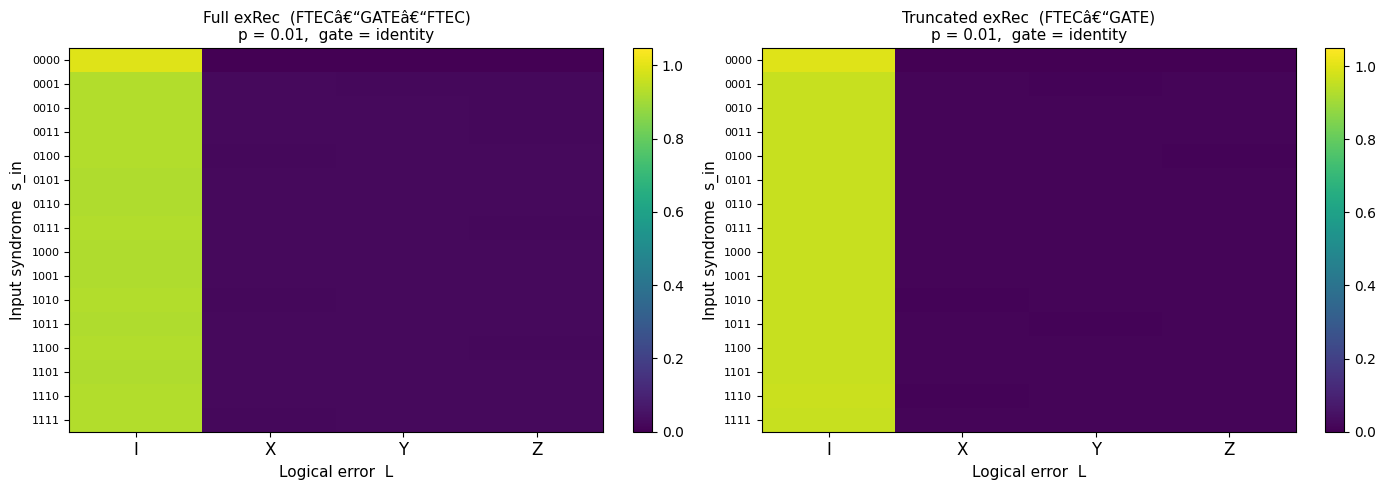

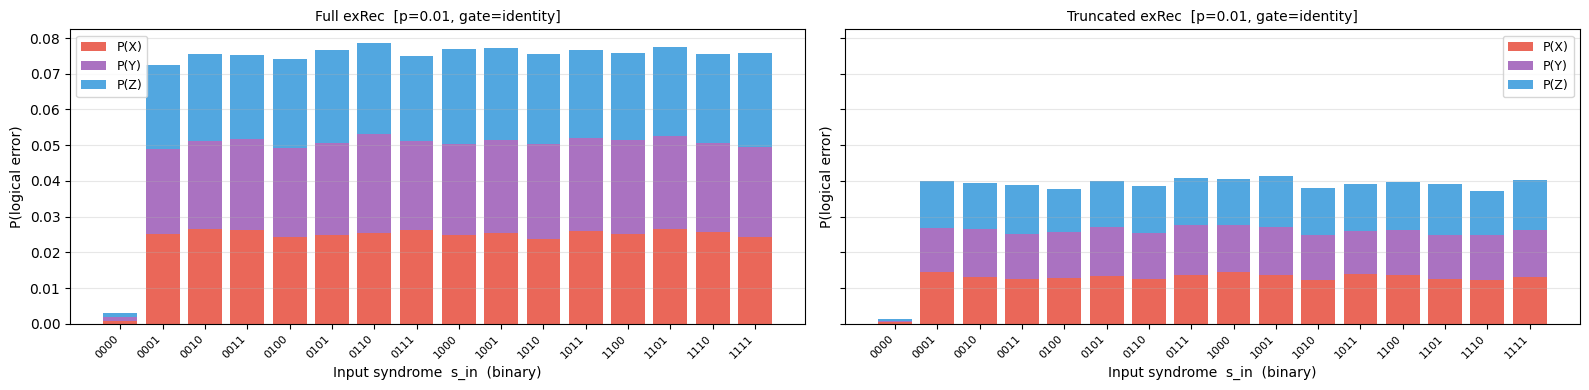

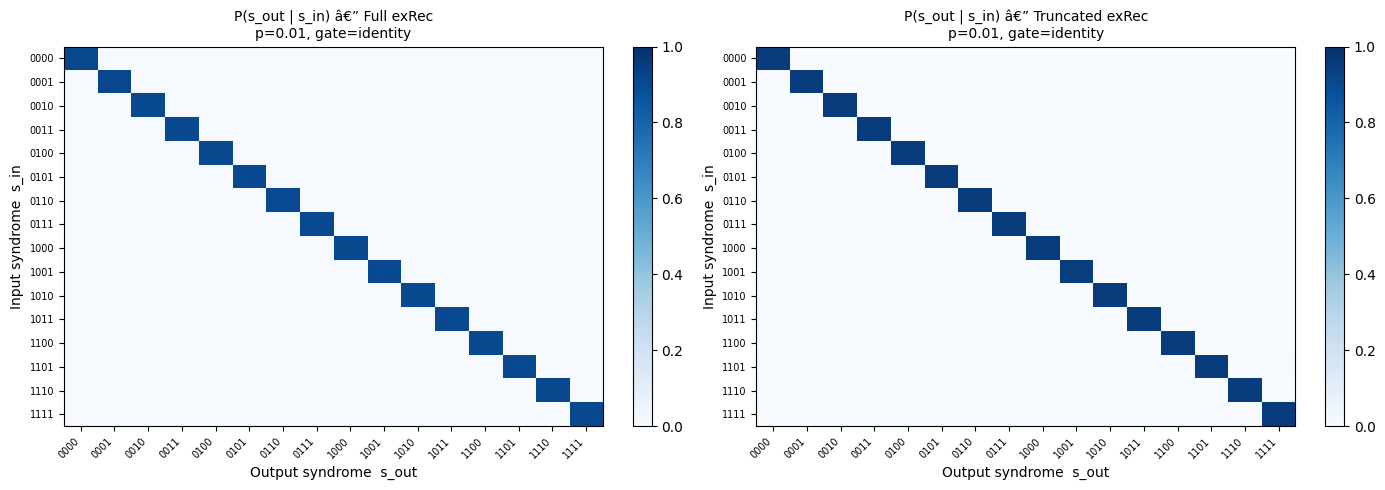

In [22]:
def plot_logical_error_heatmaps(marg_full, marg_trunc, code, p, gate_name='identity'):
    """
    Side-by-side heatmaps of P(L | s_in) for full and truncated exRec.
    """
    n_syn = code.n_syndromes
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    titles = ['Full exRec  (FTECâ€“GATEâ€“FTEC)', 'Truncated exRec  (FTECâ€“GATE)']
    for ax, title, marg in zip(axes, titles, [marg_full, marg_trunc]):
        im = ax.imshow(marg, aspect='auto', cmap='viridis', vmin=0, vmax=marg.max() * 1.05)
        ax.set_xticks(range(4))
        ax.set_xticklabels(['I', 'X', 'Y', 'Z'], fontsize=12)
        ax.set_yticks(range(n_syn))
        ax.set_yticklabels([f'{s:0{code.r}b}' for s in range(n_syn)], fontsize=8)
        ax.set_xlabel('Logical error  L', fontsize=11)
        ax.set_ylabel('Input syndrome  s_in', fontsize=11)
        ax.set_title(f'{title}\np = {p},  gate = {gate_name}', fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.show()


def plot_error_rate_by_syndrome(marg_full, marg_trunc, code, p, gate_name='identity'):
    """
    Stacked bar chart: P(X|s_in), P(Y|s_in), P(Z|s_in) per syndrome.
    """
    n_syn  = code.n_syndromes
    x      = np.arange(n_syn)
    colors = {'X': '#e74c3c', 'Y': '#9b59b6', 'Z': '#3498db'}
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
    for ax, title, marg in zip(axes,
                                ['Full exRec', 'Truncated exRec'],
                                [marg_full, marg_trunc]):
        pX, pY, pZ = marg[:, 1], marg[:, 2], marg[:, 3]
        ax.bar(x, pX, label='P(X)', color=colors['X'], alpha=0.85)
        ax.bar(x, pY, bottom=pX, label='P(Y)', color=colors['Y'], alpha=0.85)
        ax.bar(x, pZ, bottom=pX+pY, label='P(Z)', color=colors['Z'], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{s:0{code.r}b}' for s in range(n_syn)],
                           rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('Input syndrome  s_in  (binary)', fontsize=10)
        ax.set_ylabel('P(logical error)', fontsize=10)
        ax.set_title(f'{title}  [p={p}, gate={gate_name}]', fontsize=10)
        ax.legend(fontsize=9)
        ax.yaxis.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_syndrome_propagation(dist_full, dist_trunc, code, p, gate_name='identity'):
    """
    Heatmap of P(s_out | s_in) marginalised over L.
    """
    n_syn = code.n_syndromes
    prop_full  = dist_full.sum(axis=2)   # (n_syn, n_syn)
    prop_trunc = dist_trunc.sum(axis=2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, title, prop in zip(axes, ['Full exRec', 'Truncated exRec'],
                                [prop_full, prop_trunc]):
        im = ax.imshow(prop, aspect='auto', cmap='Blues', vmin=0, vmax=1)
        labels = [f'{s:0{code.r}b}' for s in range(n_syn)]
        ax.set_xticks(range(n_syn)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(n_syn)); ax.set_yticklabels(labels, fontsize=7)
        ax.set_xlabel('Output syndrome  s_out', fontsize=10)
        ax.set_ylabel('Input syndrome  s_in', fontsize=10)
        ax.set_title(f'P(s_out | s_in) â€” {title}\np={p}, gate={gate_name}', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------
# Compute truncated exRec via MC and plot
# -----------------------------------------------------------------------
print(f'Running Monte Carlo  (truncated exRec, identity gate, {N_SAMPLES} samples)...')
dist_trunc, _ = monte_carlo_distribution(
    code_513, gate_identity, p=p_val,
    exrec_type='truncated', n_samples=N_SAMPLES, seed=43
)
marg_trunc = marginal_L_given_sin(dist_trunc)

plot_logical_error_heatmaps(marg_full, marg_trunc, code_513, p=p_val)
plot_error_rate_by_syndrome(marg_full, marg_trunc, code_513, p=p_val)
plot_syndrome_propagation(dist_full, dist_trunc, code_513, p=p_val)


## Compare gate types: identity vs Hadamard
The [[5,1,3]] code supports transversal Hadamard (logical HÌ„).  Comparing the two gates shows how the gate type shifts the error basis.

  MC: gate=identity, exrec=full ... done
  MC: gate=identity, exrec=truncated ... done
  MC: gate=hadamard, exrec=full ... done
  MC: gate=hadamard, exrec=truncated ... done


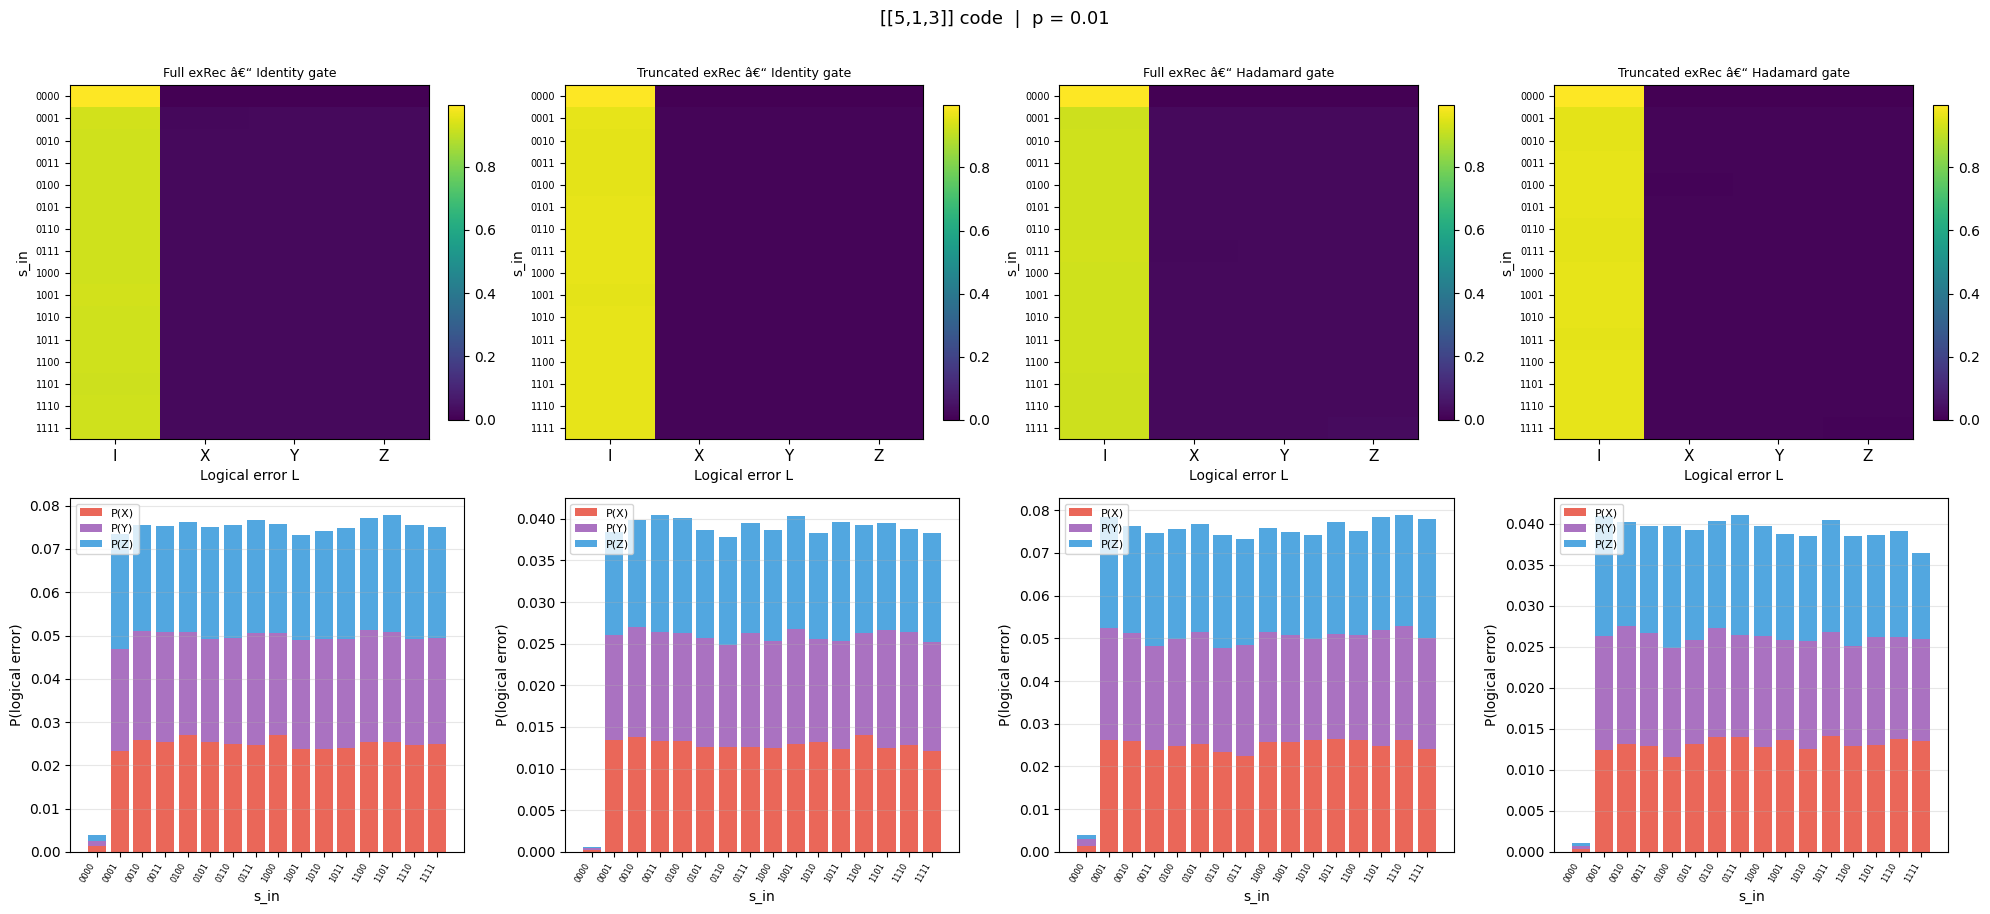

In [23]:
gate_configs = [
    ('identity',  gate_identity,  'full'),
    ('identity',  gate_identity,  'truncated'),
    ('hadamard',  gate_hadamard,  'full'),
    ('hadamard',  gate_hadamard,  'truncated'),
]

results = {}
for gate_name, gate_fn, rec_type in gate_configs:
    key = (gate_name, rec_type)
    print(f'  MC: gate={gate_name}, exrec={rec_type} ...', end=' ', flush=True)
    d, _ = monte_carlo_distribution(
        code_513, gate_fn, p=p_val, exrec_type=rec_type, n_samples=N_SAMPLES
    )
    results[key] = {'dist': d, 'marg': marginal_L_given_sin(d)}
    print('done')

# -----------------------------------------------------------------------
# Heatmap: P(L | s_in) for all four combinations
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
combos = [
    ('identity',  'full',      'Full exRec â€“ Identity gate'),
    ('identity',  'truncated', 'Truncated exRec â€“ Identity gate'),
    ('hadamard',  'full',      'Full exRec â€“ Hadamard gate'),
    ('hadamard',  'truncated', 'Truncated exRec â€“ Hadamard gate'),
]
n_syn      = code_513.n_syndromes
bin_labels = [f'{s:04b}' for s in range(n_syn)]

for col, (gname, rtype, title) in enumerate(combos):
    marg = results[(gname, rtype)]['marg']

    ax0 = axes[0, col]
    im = ax0.imshow(marg, aspect='auto', cmap='viridis', vmin=0)
    ax0.set_xticks(range(4)); ax0.set_xticklabels(['I','X','Y','Z'], fontsize=11)
    ax0.set_yticks(range(n_syn)); ax0.set_yticklabels(bin_labels, fontsize=7)
    ax0.set_xlabel('Logical error L'); ax0.set_ylabel('s_in')
    ax0.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax0, fraction=0.04)

    ax1 = axes[1, col]
    pX, pY, pZ = marg[:,1], marg[:,2], marg[:,3]
    x = np.arange(n_syn)
    ax1.bar(x, pX, color='#e74c3c', label='P(X)', alpha=0.85)
    ax1.bar(x, pY, bottom=pX, color='#9b59b6', label='P(Y)', alpha=0.85)
    ax1.bar(x, pZ, bottom=pX+pY, color='#3498db', label='P(Z)', alpha=0.85)
    ax1.set_xticks(x); ax1.set_xticklabels(bin_labels, rotation=60, ha='right', fontsize=6)
    ax1.set_xlabel('s_in'); ax1.set_ylabel('P(logical error)')
    ax1.legend(fontsize=8); ax1.yaxis.grid(True, alpha=0.3)

plt.suptitle(f'[[5,1,3]] code  |  p = {p_val}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Non-Markovianity measure
A quantitative measure of how much the logical error probabilities depend on `s_in`. If the exRec were Markovian (abstract EC limit), `P(L | s_in)` would be independent of `s_in`.

Non-Markovianity  NM  (avg TVD from syndrome-average)
Config                                            NM    P_avg(I)  P_avg(X)  P_avg(Y)  P_avg(Z)
------------------------------------------------------------------------------------------
  gate=identity    exrec=full           8.41e-03     0.929066  0.023565  0.023307  0.024062
  gate=identity    exrec=truncated      4.52e-03     0.963254  0.012142  0.012246  0.012358
  gate=hadamard    exrec=full           8.54e-03     0.928418  0.023637  0.023936  0.024009
  gate=hadamard    exrec=truncated      4.70e-03     0.963002  0.012366  0.012230  0.012402

Sweeping p  (MC, 200000 samples/point, identity gate) ...
  p=0.0001  NM(full)=2.696e-04  NM(trunc)=2.152e-04
  p=0.0001  NM(full)=3.594e-04  NM(trunc)=2.759e-04
  p=0.0002  NM(full)=4.416e-04  NM(trunc)=3.284e-04
  p=0.0003  NM(full)=5.777e-04  NM(trunc)=4.740e-04
  p=0.0004  NM(full)=7.247e-04  NM(trunc)=6.000e-04
  p=0.0006  NM(full)=9.266e-04  NM(trunc)=6.843e-04
  p=0.0009  NM(full)=

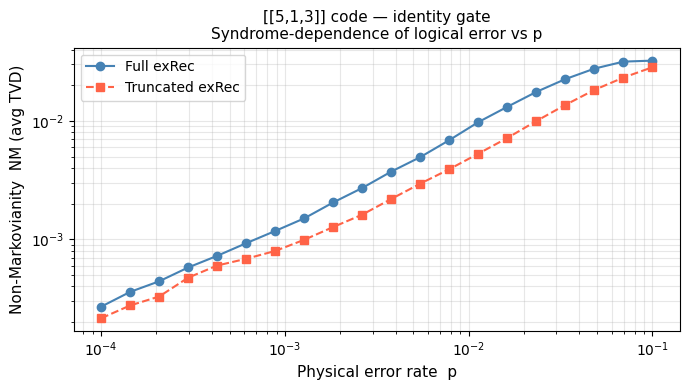

In [24]:
# -----------------------------------------------------------------------
# NM table for the four gate/exrec combinations already computed above
# -----------------------------------------------------------------------
print('Non-Markovianity  NM  (avg TVD from syndrome-average)')
print(f'{"Config":<40}  {"NM":>10}  {"P_avg(I)":>10}  {"P_avg(X)":>8}  {"P_avg(Y)":>8}  {"P_avg(Z)":>8}')
print('-' * 90)
for (gname, rtype), res in results.items():
    nm, p_avg = non_markovianity(res['marg'])
    print(f'  gate={gname:<10}  exrec={rtype:<10}   '
          f'{nm:10.2e}   {p_avg[0]:10.6f}  {p_avg[1]:8.6f}  {p_avg[2]:8.6f}  {p_avg[3]:8.6f}')

# -----------------------------------------------------------------------
# NM vs p — sweep using MC  (fewer samples per point is fine for the trend)
# -----------------------------------------------------------------------
p_range       = np.logspace(-4, -1, 20)
MC_SWEEP      = 200_000   # samples per p-value during sweep
nm_full_arr   = []
nm_trunc_arr  = []

print(f'\nSweeping p  (MC, {MC_SWEEP} samples/point, identity gate) ...')
for pv in p_range:
    d_f, _ = monte_carlo_distribution(code_513, gate_identity, pv, 'full',
                                       n_samples=MC_SWEEP, seed=0)
    d_t, _ = monte_carlo_distribution(code_513, gate_identity, pv, 'truncated',
                                       n_samples=MC_SWEEP, seed=1)
    nm_f, _ = non_markovianity(marginal_L_given_sin(d_f))
    nm_t, _ = non_markovianity(marginal_L_given_sin(d_t))
    nm_full_arr.append(nm_f)
    nm_trunc_arr.append(nm_t)
    print(f'  p={pv:.4f}  NM(full)={nm_f:.3e}  NM(trunc)={nm_t:.3e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(p_range, nm_full_arr,  'o-',  label='Full exRec',      color='steelblue')
ax.loglog(p_range, nm_trunc_arr, 's--', label='Truncated exRec', color='tomato')
ax.set_xlabel('Physical error rate  p', fontsize=11)
ax.set_ylabel('Non-Markovianity  NM (avg TVD)', fontsize=11)
ax.set_title('[[5,1,3]] code — identity gate\nSyndrome-dependence of logical error vs p', fontsize=11)
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()